# Forschungsfrage 1 - Duplikate: Moderner Non-LLM-Ansatz (Splink)

Dieses Notebook implementiert den **modernen, nicht-generativen** Ansatz zur
Duplikaterkennung (vgl. Abschnitt 3.3.1): probabilistisches Record Linkage mit
[Splink](https://moj-analytical-services.github.io/splink/) (Version 4, UK Ministry
of Justice), basierend auf dem Fellegi-Sunter-Modell (Fellegi & Sunter, 1969).

**Kernunterschied zu den bisherigen Ansätzen:** Bei `Forschungsfrage_1_Duplikate_ExactRapidFuzz.ipynb`
wurden die Gewichte der Vergleichssignale (URL-Exaktheit, Titel-Ähnlichkeit, Boni) von Hand
festgelegt. Bei `Forschungsfrage_1_Duplikate_XGBoost.ipynb` musste ein Klassifikator mit
gelabelten Trainingsdaten (`train`-Split) trainiert werden. Splink benötigt **keine Labels**:
Für jedes Vergleichsfeld werden zwei Wahrscheinlichkeiten aus der Datenstruktur selbst gelernt -
per Expectation-Maximization (EM), vollständig unüberwacht:

- **m-Wahrscheinlichkeit:** Wie wahrscheinlich ist dieses Ähnlichkeitsniveau (z.B. "Titel
  identisch"), *gegeben* dass beide Datensätze wirklich dasselbe Angebot beschreiben?
- **u-Wahrscheinlichkeit:** Wie wahrscheinlich ist dasselbe Ähnlichkeitsniveau *zufällig*,
  *gegeben* dass es sich um zwei unterschiedliche Angebote handelt?

Das Verhältnis m/u (als log2-Bayes-Faktor ausgedrückt) zeigt, wie viel Beweiskraft ein Feld
trägt - und wird von Splink direkt aus den Daten geschätzt, nicht von mir vorgegeben.

**Verwendete Daten:** dieselben `benchmark/tf1_duplicate_pool.csv` und
`benchmark/tf1_duplicate_pairs.csv` wie bei RapidFuzz und XGBoost - identischer `test`-Split
für die faire Vergleichbarkeit aller Methoden.


## 1. Setup und Daten laden

In [1]:
import pandas as pd
import numpy as np
import re
import html
import json
import time
import os
from urllib.parse import urlsplit, parse_qs, unquote

from splink import Linker, DuckDBAPI, SettingsCreator
import splink.comparison_library as cl
import splink.comparison_level_library as cll
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

os.makedirs("results", exist_ok=True)

pool = pd.read_csv("benchmark/tf1_duplicate_pool.csv")
pairs = pd.read_csv("benchmark/tf1_duplicate_pairs.csv")

print(f"Pool: {pool.shape[0]} Zeilen ({pool['is_synthetic'].sum()} davon synthetisch)")
print(f"Paare: {pairs.shape[0]} ({pairs['label'].sum()} Duplikate, {(pairs['label']==0).sum()} Nicht-Duplikate)")


Pool: 1476 Zeilen (150 davon synthetisch)
Paare: 736 (184 Duplikate, 552 Nicht-Duplikate)


## 2. Merkmalsvorbereitung

Dieselben Vorverarbeitungsschritte wie im RapidFuzz-Notebook, wiederverwendet:
`normalize_url()` (inkl. der dort entdeckten Korrekturen für HTML-Entities und
Amazon-Affiliate-Redirect-Links) und die numerische Preis-Extraktion. Zusätzlich wird
`creation_date` in ein ISO-Format überführt, das Splinks Datumsvergleichsfunktion
benötigt.


In [2]:
def normalize_url(u):
    """Identisch zur Funktion aus Forschungsfrage_1_Duplikate_ExactRapidFuzz.ipynb -
    entpackt Amazon-Redirect-Links und behandelt HTML-Entities in den Roh-URLs."""
    if pd.isna(u):
        return None
    s = html.unescape(str(u).strip())
    if not s:
        return None
    parts = urlsplit(s)
    qs = parse_qs(parts.query)
    for key in ("location", "url", "u", "q", "dest"):
        if key in qs and qs[key]:
            inner = unquote(qs[key][0])
            if inner and inner != s:
                return normalize_url(inner)
    path = parts.path.rstrip("/")
    return f"{parts.netloc}{path}".lower()

def extract_price_num(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r"(\d+(?:\.\d+)?)", str(val))
    return float(m.group(1)) if m else np.nan

def parse_pool_date(s):
    if pd.isna(s):
        return pd.NaT
    s2 = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", str(s))
    try:
        return pd.to_datetime(s2, format="%b %d, %Y %I:%M %p")
    except ValueError:
        return pd.to_datetime(s2, errors="coerce")

pool["url_norm"] = pool["url"].apply(normalize_url)
pool["title_lower"] = pool["title"].astype(str).str.lower()
pool["price_num"] = pool["price"].apply(extract_price_num)
pool["creation_date_iso"] = pool["creation_date"].apply(parse_pool_date).dt.strftime("%Y-%m-%d %H:%M:%S")

pool[["row_id", "url_norm", "title_lower", "price_num", "creation_date_iso"]].head()


,row_id,url_norm,title_lower,price_num,creation_date_iso
0,0,www.staples.ca/products/833572-en-one-step-han...,"one step hand sanitizer, fragrance-free, 473ml...",6.99,2020-07-16 08:29:00
1,1,NaN,ryobi 20% coupon barcode,NaN,2020-07-13 13:29:00
2,2,www.kits.com/freeglasses.html,kits.com free pair prescription glasses,NaN,2020-07-02 10:03:00
3,3,www.costco.ca/northrock-xc00-fat-tire-bike.pro...,"northrock xc00, fat tire bike, $469.99",469.99,2020-07-17 07:23:00
4,4,NaN,60x total ct money when you pay with your tria...,NaN,2020-07-16 13:36:00


## 3. Splink-Modell definieren

Fünf Vergleiche, dieselben Felder wie bei RapidFuzz, aber jetzt als Splink-`Comparison`-
Objekte mit mehreren abgestuften Ähnlichkeitsniveaus statt eines einzelnen Scores:

- `url_norm`: exakte Übereinstimmung ja/nein.
- `title_lower`: Jaro-Winkler-Ähnlichkeit, gestuft bei >=0.9 und >=0.7.
- `author`: exakte Übereinstimmung ja/nein.
- `price_num`: exakt gleich, oder Differenz <= 0.01 (Rundungstoleranz), oder verschieden
  (eigene `CustomComparison`, da Splink keine eingebaute reine Zahlendifferenz-Vergleichsklasse
  für beliebige Werte hat).
- `creation_date_iso`: exakt gleiche Sekunde, oder Differenz <= 72 Stunden (identisch zur
  Boni-Regel bei RapidFuzz), oder weiter auseinander.

**Blocking:** Der Pool hat nur 1476 Zeilen (~1,09 Mio. mögliche Paare) - für DuckDB
unproblematisch. Die Blocking-Regel `"1=1"` erzeugt daher *alle* Paare, ohne dass reale
oder synthetische Duplikate durch eine zu enge Blocking-Regel verloren gehen könnten.


In [3]:
settings = SettingsCreator(
    link_type="dedupe_only",
    unique_id_column_name="row_id",
    comparisons=[
        cl.ExactMatch("url_norm"),
        cl.JaroWinklerAtThresholds("title_lower", [0.9, 0.7]),
        cl.ExactMatch("author"),
        cl.CustomComparison(
            output_column_name="price_num",
            comparison_levels=[
                cll.NullLevel("price_num"),
                cll.ExactMatchLevel("price_num"),
                cll.AbsoluteDifferenceLevel("price_num", 0.01),
                cll.ElseLevel(),
            ],
        ),
        cl.AbsoluteTimeDifferenceAtThresholds(
            "creation_date_iso", input_is_string=True, metrics="hour", thresholds=[72],
            datetime_format="%Y-%m-%d %H:%M:%S",
        ),
    ],
    blocking_rules_to_generate_predictions=["1=1"],
    retain_intermediate_calculation_columns=True,
)

db_api = DuckDBAPI()
linker = Linker(pool, settings, db_api=db_api)
print("Linker initialisiert.")


Linker initialisiert.


## 4. Training: unüberwachte Parameterschätzung (u dann m, per EM)

**Wichtig:** An dieser Stelle wird der `train`-Split verwendet - aber anders als bei
XGBoost **ohne** die Label-Spalte. Splink sieht nur die Rohdaten aller 1476 Pool-Zeilen und
lernt die m-/u-Wahrscheinlichkeiten rein aus der Verteilung der Ähnlichkeiten selbst.


In [4]:
t0 = time.time()
linker.training.estimate_u_using_random_sampling(max_pairs=1e6, seed=42)
em_session = linker.training.estimate_parameters_using_expectation_maximisation("1=1")
train_time = time.time() - t0
print(f"\nTrainingszeit (u-Schaetzung + EM): {train_time:.2f}s")


You are using the default value for `max_pairs`, which may be too small and thus lead to inaccurate estimates for your model's u-parameters. Consider increasing to 1e8 or 1e9, which will result in more accurate estimates, but with a longer run time.


----- Estimating u probabilities using random sampling -----



Estimated u probabilities using random sampling



Your model is not yet fully trained. Missing estimates for:
    - url_norm (no m values are trained).
    - title_lower (no m values are trained).
    - author (no m values are trained).
    - price_num (no m values are trained).
    - creation_date_iso (no m values are trained).



----- Starting EM training session -----



...

Iteration 18: Largest change in params was 0.000117 in the m_probability of title_lower, level `Jaro-Winkler distance of title_lower >= 0.7`


Iteration 19: Largest change in params was 7.97e-05 in the m_probability of title_lower, level `Jaro-Winkler distance of title_lower >= 0.7`



EM converged after 19 iterations



Your model is fully trained. All comparisons have at least one estimate for their m and u values



Trainingszeit (u-Schaetzung + EM): 8.78s


## 5. Gelernte Spaltengewichte: Bayes-Faktoren je Vergleichsniveau

Für Abschnitt 4.1.4/4.1.5: Welche Spalte trägt laut Splink wie viel Beweiskraft? Der
log2-Bayes-Faktor (log2(m/u)) ist direkt mit der Bit-Interpretation des `match_weight`
verknüpft, den Splink für die finale Vorhersage aufsummiert.


In [5]:
import math

linker.misc.save_model_to_json("results/tf1_splink_model.json", overwrite=True)
model = json.load(open("results/tf1_splink_model.json"))

rows = []
for comp in model["comparisons"]:
    for lvl in comp["comparison_levels"]:
        m, u = lvl.get("m_probability"), lvl.get("u_probability")
        if m is None or u is None or u == 0:
            continue
        rows.append({
            "Spalte": comp["output_column_name"],
            "Vergleichsniveau": lvl.get("label_for_charts"),
            "m_probability": round(m, 4), "u_probability": round(u, 6),
            "log2_bayes_faktor": round(math.log2(m / u), 2),
        })
weights_table = pd.DataFrame(rows).sort_values("log2_bayes_faktor", ascending=False)
weights_table.to_csv("results/tf1_splink_column_weights.csv", index=False)
weights_table


,Spalte,Vergleichsniveau,m_probability,u_probability,log2_bayes_faktor
3,title_lower,Jaro-Winkler distance of title_lower >= 0.9,0.5426,0.000120,12.15
2,title_lower,Exact match on title_lower,0.2656,0.000058,12.15
11,creation_date_iso,Exact match on creation_date_iso,0.0791,0.000046,10.73
6,author,Exact match on author,0.5466,0.001659,8.36
8,price_num,Exact match on price_num,0.9658,0.003901,7.95
4,title_lower,Jaro-Winkler distance of title_lower >= 0.7,0.1371,0.000607,7.82
0,url_norm,Exact match on url_norm,0.9655,0.006407,7.24
12,creation_date_iso,Abs difference of 'transformed creation_date_i...,0.8582,0.161563,2.41
7,author,All other comparisons,0.4534,0.998341,-1.14
13,creation_date_iso,All other comparisons,0.0627,0.838390,-3.74


## 6. Vorhersage auf allen Paaren, Abgleich mit dem Benchmark

In [6]:
t1 = time.time()
predictions = linker.inference.predict()
df_pred = predictions.as_pandas_dataframe()
predict_time = time.time() - t1
print(f"Vorhersagezeit (alle {df_pred.shape[0]} Paare): {predict_time:.2f}s")

# Abgleich per sortiertem (row_id_a, row_id_b)-Schluessel, da Splink l/r nicht
# garantiert in derselben Reihenfolge wie unser Benchmark ausgibt.
pairs["key"] = pairs.apply(lambda r: tuple(sorted((r["row_id_a"], r["row_id_b"]))), axis=1)
df_pred["key"] = df_pred.apply(lambda r: tuple(sorted((r["row_id_l"], r["row_id_r"]))), axis=1)
scored = pairs.merge(df_pred[["key", "match_probability"]], on="key", how="left")

assert scored["match_probability"].isna().sum() == 0, "Nicht alle Benchmark-Paare wurden von Splink bewertet!"
print(f"Alle {len(scored)} Benchmark-Paare erfolgreich mit match_probability versehen.")


Blocking time: 0.00 seconds


Predict time: 5.29 seconds


Vorhersagezeit (alle 1088550 Paare): 29.85s


Alle 736 Benchmark-Paare erfolgreich mit match_probability versehen.


## 7. Schwellenwert-Kalibrierung auf dem `val`-Split

Identische Methodik wie bei RapidFuzz: Schwellenwert auf `match_probability` wird auf dem
`val`-Split gewählt (F1-Maximierung), der `test`-Split bleibt unberührt.


In [7]:
val = scored[scored["split"] == "val"]

thresholds = np.round(np.arange(0.0, 1.001, 0.01), 3)
best_threshold, best_f1 = 0.0, -1
curve_rows = []
for thr in thresholds:
    pred = (val["match_probability"] >= thr).astype(int)
    f1 = f1_score(val["label"], pred, zero_division=0)
    curve_rows.append({"threshold": thr, "f1_val": f1})
    if f1 > best_f1:
        best_f1, best_threshold = f1, thr

threshold_curve = pd.DataFrame(curve_rows)
print(f"Bester Schwellenwert (auf val-Split, {len(val)} Paare): {best_threshold} (F1_val={best_f1:.3f})")


Bester Schwellenwert (auf val-Split, 147 Paare): 0.01 (F1_val=0.986)


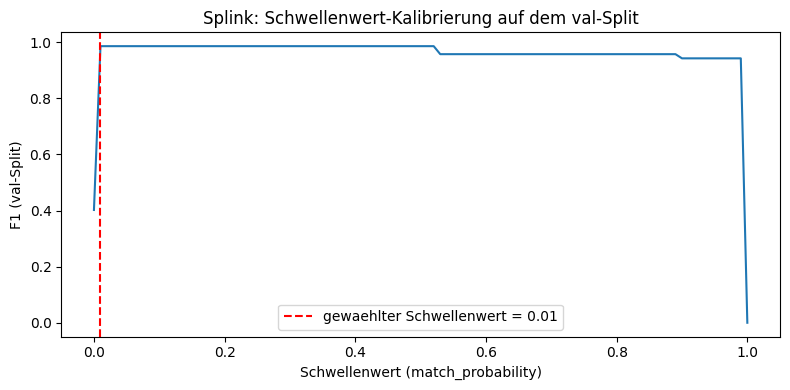

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(threshold_curve["threshold"], threshold_curve["f1_val"])
plt.axvline(best_threshold, color="red", linestyle="--", label=f"gewaehlter Schwellenwert = {best_threshold}")
plt.xlabel("Schwellenwert (match_probability)")
plt.ylabel("F1 (val-Split)")
plt.title("Splink: Schwellenwert-Kalibrierung auf dem val-Split")
plt.legend()
plt.tight_layout()
plt.savefig("results/tf1_splink_threshold_curve.png", dpi=120)
plt.show()


## 8. Evaluation auf dem `test`-Split (finales, berichtetes Ergebnis)

In [9]:
test = scored[scored["split"] == "test"].copy()
test["prediction"] = (test["match_probability"] >= best_threshold).astype(int)

precision = precision_score(test["label"], test["prediction"])
recall = recall_score(test["label"], test["prediction"])
f1 = f1_score(test["label"], test["prediction"])

print(f"Test-Split ({len(test)} Paare), Schwellenwert={best_threshold}")
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
print()
print(classification_report(test["label"], test["prediction"], target_names=["kein Duplikat", "Duplikat"]))
print("Konfusionsmatrix:")
print(confusion_matrix(test["label"], test["prediction"]))


Test-Split (148 Paare), Schwellenwert=0.01
Precision: 1.000  Recall: 0.973  F1: 0.986

               precision    recall  f1-score   support

kein Duplikat       0.99      1.00      1.00       111
     Duplikat       1.00      0.97      0.99        37

     accuracy                           0.99       148
    macro avg       1.00      0.99      0.99       148
 weighted avg       0.99      0.99      0.99       148

Konfusionsmatrix:
[[111   0]
 [  1  36]]


## 9. Fehleranalyse

Für die qualitative Diskussion in Abschnitt 4.1.5, direkt vergleichbar mit den
Falsch-Klassifikationen von RapidFuzz und XGBoost auf demselben `test`-Split.


In [10]:
pool_idx = pool.set_index("row_id")

def show_pair(row):
    a, b = pool_idx.loc[row["row_id_a"]], pool_idx.loc[row["row_id_b"]]
    return {"title_a": a["title"], "title_b": b["title"],
            "match_probability": round(row["match_probability"], 4),
            "label": row["label"], "prediction": row["prediction"]}

fp = test[(test["label"] == 0) & (test["prediction"] == 1)]
fn = test[(test["label"] == 1) & (test["prediction"] == 0)]
print(f"Falsch-Positive: {len(fp)}, Falsch-Negative: {len(fn)}")

fehler_beispiele = pd.DataFrame([show_pair(r) for _, r in pd.concat([fp, fn]).iterrows()])
fehler_beispiele


Falsch-Positive: 0, Falsch-Negative: 1


,title_a,title_b,match_probability,label,prediction
0,"Kawasaki 1.2 GPM @ 1,650 PSI Electric Pressure...",Kawasaki 1650 PSI Pressure Washer $139,0.004,1,0


## 10. Ergebnisse und Laufzeit-Log speichern

In [11]:
test_out = test[["row_id_a", "row_id_b", "label", "match_probability", "prediction"]].copy()
test_out.to_csv("results/tf1_splink_predictions.csv", index=False)

metrics = {
    "experiment": "TF1_Duplikate", "method": "Splink", "n_test": len(test),
    "threshold": best_threshold, "f1_val_at_threshold": best_f1,
    "precision": precision, "recall": recall, "f1": f1,
    "train_time_sec": train_time, "predict_time_sec": predict_time,
    "n_false_positives": int(len(fp)), "n_false_negatives": int(len(fn)),
}
with open("results/tf1_splink_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

log_row = pd.DataFrame([{
    "experiment": "TF1_Duplikate", "method": "Splink", "n_items": len(test),
    "wall_time_sec": train_time + predict_time, "input_tokens": 0, "output_tokens": 0,
    "estimated_cost_usd": 0.0, "model_name": "splink-4.0 (Fellegi-Sunter, EM, kein LLM/API)",
}])
log_path = "results/laufzeit_kosten_log.csv"
if os.path.exists(log_path):
    _old_log = pd.read_csv(log_path)
    _new_keys = set(zip(log_row["experiment"], log_row["method"]))
    _old_log = _old_log[~_old_log.apply(lambda r: (r["experiment"], r["method"]) in _new_keys, axis=1)]
    _combined_log = pd.concat([_old_log, log_row], ignore_index=True)
else:
    _combined_log = log_row
_combined_log.to_csv(log_path, index=False)

print("Gespeichert: results/tf1_splink_predictions.csv, results/tf1_splink_metrics.json, "
      "results/tf1_splink_column_weights.csv")
print("Laufzeit-Log aktualisiert: results/laufzeit_kosten_log.csv")
print(json.dumps(metrics, indent=2))


Gespeichert: results/tf1_splink_predictions.csv, results/tf1_splink_metrics.json, results/tf1_splink_column_weights.csv
Laufzeit-Log aktualisiert: results/laufzeit_kosten_log.csv
{
  "experiment": "TF1_Duplikate",
  "method": "Splink",
  "n_test": 148,
  "threshold": 0.01,
  "f1_val_at_threshold": 0.9863013698630136,
  "precision": 1.0,
  "recall": 0.972972972972973,
  "f1": 0.9863013698630136,
  "train_time_sec": 8.775821685791016,
  "predict_time_sec": 29.849238872528076,
  "n_false_positives": 0,
  "n_false_negatives": 1
}


**Hinweis für Abschnitt 4.1.4:** Im Gegensatz zu RapidFuzz (0,6s, keine Trainingsphase)
benötigt Splink eine Trainingsphase (u-Schätzung + EM), ist aber weiterhin um Größenordnungen
schneller und günstiger als der LLM-Ansatz (Abschnitt 4.1.3). Die in Abschnitt 5 extrahierte
Bayes-Faktor-Tabelle liefert zudem eine mit XGBoosts Feature-Importances vergleichbare,
aber statistisch anders begründete Rangfolge der Merkmalsrelevanz.